# Lunching ribbon simulation on auto-07p 
Make sure to correctly install all the dependencies (Numpy, scipy , pandas, matplotlib, plotly, kaleido) on your environement where you run this notebook. Follow the instructions of Auto-07p's installation and add the dependency (Numpy, scipy , pandas) inside of the Linux environemnt (where you will lunch auto) if you also want ot run the optimization part.

In [1]:
import numpy as np
from scipy import *
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize


import pandas as pd
import csv

from src import *

# Pre-processing and setup 

## Lunch Auto
Inside of our linux environnement (typically on the Ubuntu command prompt), execute the following lines.

Go inside of the file containing all the auto material: ```cd auto-07p/Semester_project/auto_files_ribbon/```

Activate the utilization of the auto environnement: ```source $HOME/auto-07p/cmds/auto.env.sh```

Lunch Auto: ```auto```

## Setup Auto .f90 file for a specific load case

To setup a specific load case, you need to change the definition of the stress along the ribbon and the boundary conditions inside of the .f90 file. Open the ribbon.f90 file and search in the code for the ````!!!---external Forces---!!!```` and ````!!!---external Moments---!!!```` portion of the subroutine FUNC. There you will be able to modify fe1,fe2,fe3,me1,me2 and me3 that control the stresses and moments along the ribbon with respect to the cosserat frame. \
Then look for the subroutine BCND where the boundary conditions are defined. Seach for ````!!!---external Forces at the tip---!!!```` and ````!!!---external Moments at the tip---!!!```` to modify the loading at the tip (fe1,fe2,fe3,me1,me2 and me3) or go directly inside the definitions of FB(i) variable. (which are the boundary conditions on the stat variable) To define the FB vector correctly, keep in mind these simple rules:\
- the solver will put all the FB(i) values to zero.
- U0(i) and U1(i) are the stat vetor values at the base (where s = 0) and at the tip (where s = 1) respectively.
- Keep the boundary value problem well defined by imposing either the force nor the displacement on the same position and axis. If you want to impose displacement and the force on one position and in one direction you will have to relax an other constraints using continuation methods. (Not implem)

for exemple:
- ````FB(1)=U0(1)```` set the stat variable U(1) (position x) to be equal to 0 at the base (where s=0)\
- ````FB(13)=U1(13) - fe1```` set the stat variable U(13) (stress along d1) to be equal to fe1 (the force along d1 define earlier) at the tip (where s=1)

Also keep in mind that all quantities (forces, stress, moments, displacements) are non dimensionalized inside of Auto wich means that to apply a force in Newton you must first translate it on a non-demension variable using the **AUTO-strip-documentation.pdf** from Basile Audoly.

You can use this small code to translate between unitless and Netwon forces (relation extracted form **AUTO-strip-documentation.pdf**)

In [ ]:
L = 50      # Length [mm]
t = 0.1     # thikness [mm]
a = 5.0     # Width [mm]
Y = 2.77e1  # Youngs Modulus of the ribbon [N/mm^2]

unitless_force = 1
force_N = 2e-2

print("force = :" ,unitless_force*Y*a*t**3/(12*L**2),"N")

print("Unitless force = :" ,force_N/(Y*a*t**3)*(12*L**2), "[-]")

## Setup Auto .auto file for an optimization run 

### Create the objective configuration from a specific load case

Use the .f90 file ```ribbon.f90``` to generate a solution to use as an objective. Then process it using the cell bellow.

In [2]:
path = "//wsl.localhost/Ubuntu/home/pmaillar/auto-07p/Semester_project/auto_files_ribbon/s.mu"

solution_df = process_solution_file(path)
#index of the solution to use
index = 2
true_solution = solution_df[solution_df['Index_solution'] == index]
true_solution.to_csv('true_solution.csv', index=False)
true_solution.head(3)


Partition found 15 solutions with 1601 points each


,Cont_par,X,Y,Z,d3x,d3y,d3z,d2x,d2y,d2z,...,R1,R2,R3,m1,m2,m3,k2,k3,s,Index_solution
1601,0.000000,7.849955e-30,-7.548488e-28,1.649337e-26,1.0,-6.670310e-27,-2.515297e-26,9.834678e-28,-9.716591e-25,1.0,...,0.104913,-0.00521,0.094836,0.005207,0.101652,-0.000175,0.101552,-0.000117,-5.463934e-37,2.0
1602,0.000625,6.250000e-04,1.983008e-08,-4.836920e-16,1.0,6.344944e-05,-2.321106e-12,-2.320147e-12,7.314885e-08,1.0,...,0.104907,-0.00521,0.094843,0.005203,0.101586,-0.000175,0.101486,-0.000117,6.250000e-04,2.0
1603,0.001250,1.250000e-03,7.930328e-08,-3.866466e-15,1.0,1.268580e-04,-9.274614e-12,-9.266945e-12,1.461599e-07,1.0,...,0.104901,-0.00521,0.094849,0.005200,0.101521,-0.000175,0.101421,-0.000117,1.250000e-03,2.0


### Experimental objective configuration visualisation (May still need some formatting to be used as objective configuration)

Depending on the format of the input configuration, you may need to change:
- the name of the columns of the data in the csv file
- Scale the coodinate to have a ribbon of length 1
- rotate the ribbon to match the orientation of the initial configuration 

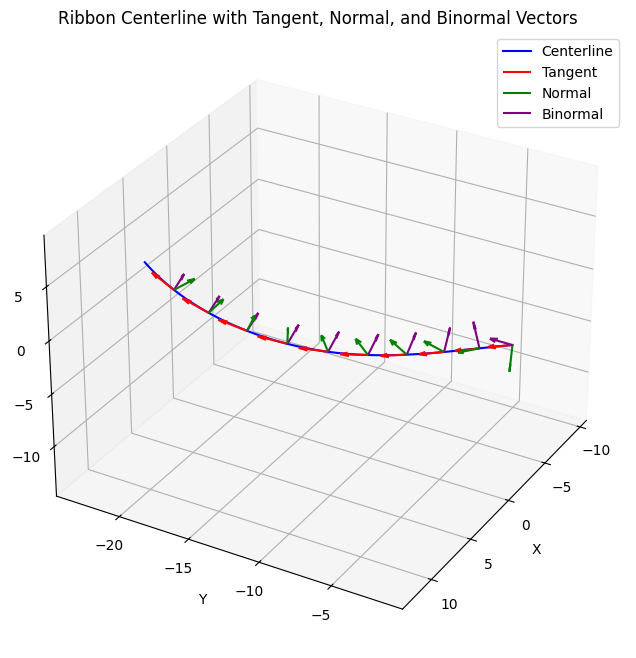

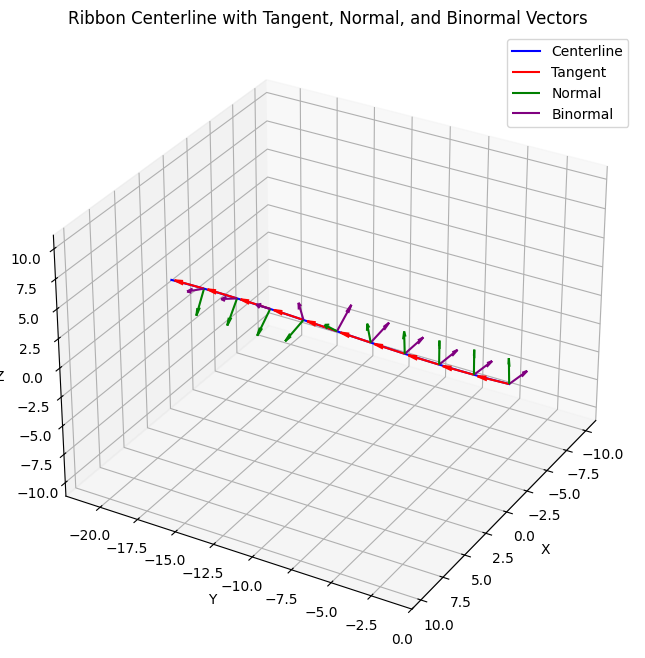

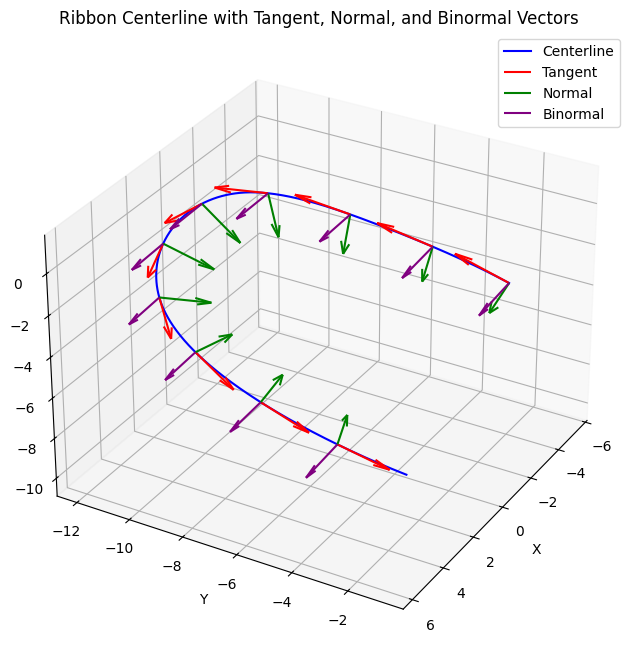

In [13]:
true_solution_12 = pd.read_csv('true_solution_input/12-1000points.csv')
plot_3D_ribbons_from_experimental_setup(true_solution_12,scale=2,vector_interval=10)

true_solution_L7R7 = pd.read_csv('true_solution_input/L7R7-1000points.csv')
plot_3D_ribbons_from_experimental_setup(true_solution_L7R7,scale=2,vector_interval=10)

true_solution_LR = pd.read_csv('true_solution_input/LR-1000points.csv')
plot_3D_ribbons_from_experimental_setup(true_solution_LR,scale=2,vector_interval=10)

# Simulation

## Specific Load case

When you are on the auto environment (activated by running the ````auto```` command), run ````auto("ribbon.auto")```` to run the continuation corresponding to the ribbon.f90 file that you set up in the pre-processing. This is a typicall output you would get:

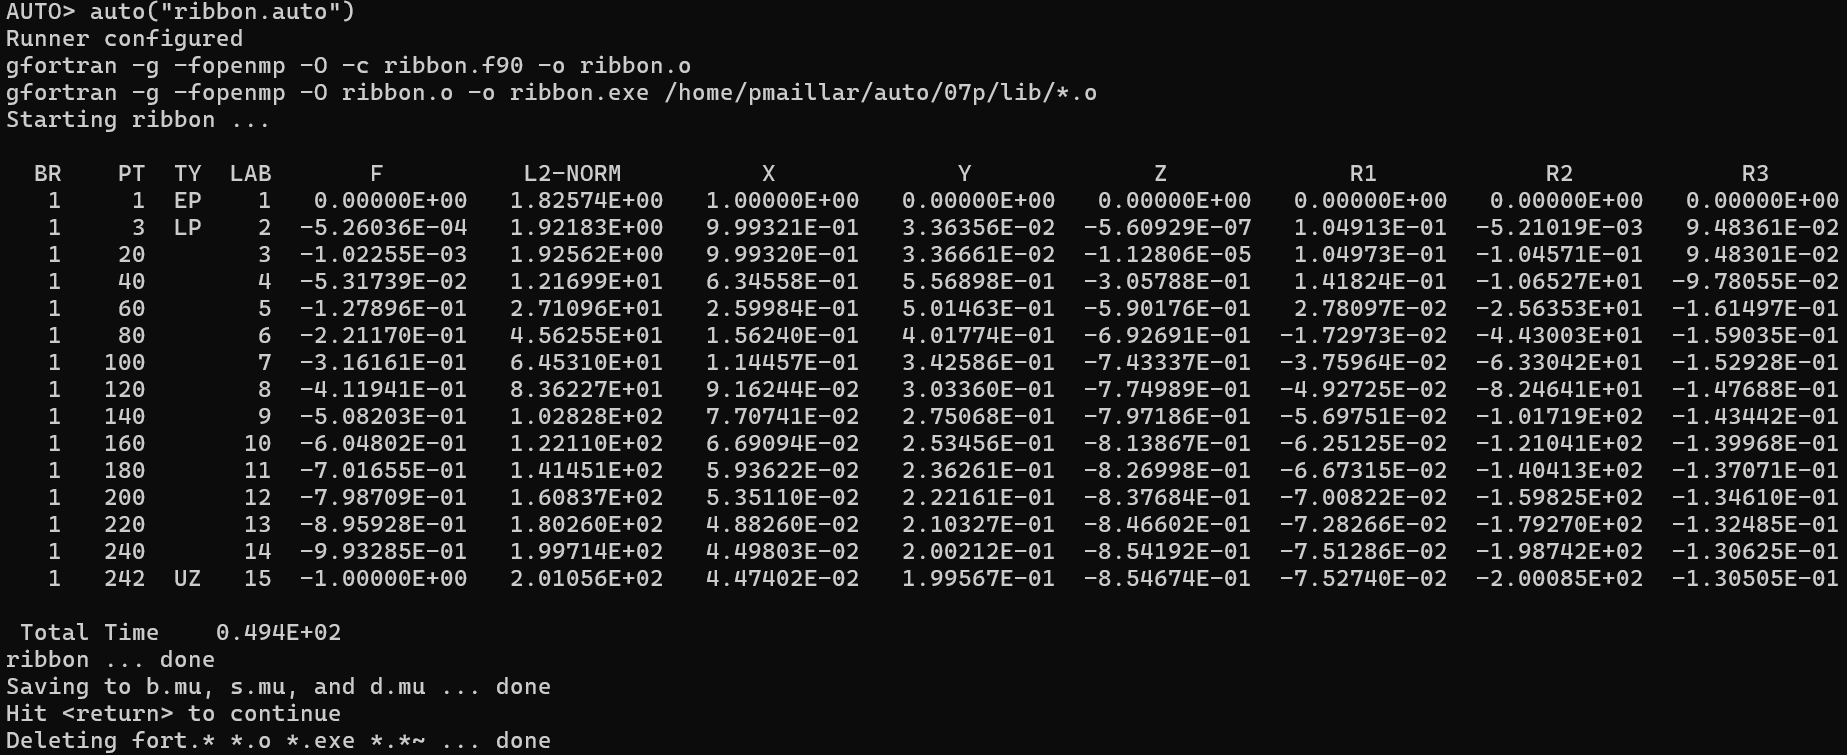

## Optimization run

When you are on the auto environment (activated by running the ````auto```` command), run ````auto("ribbon_IFEM.auto")```` to run the continuation corresponding to the ribbon_IFEM.f90 and ribbon_IFEM.auto files that you set up in the pre-processing. This is a typicall output you would get:

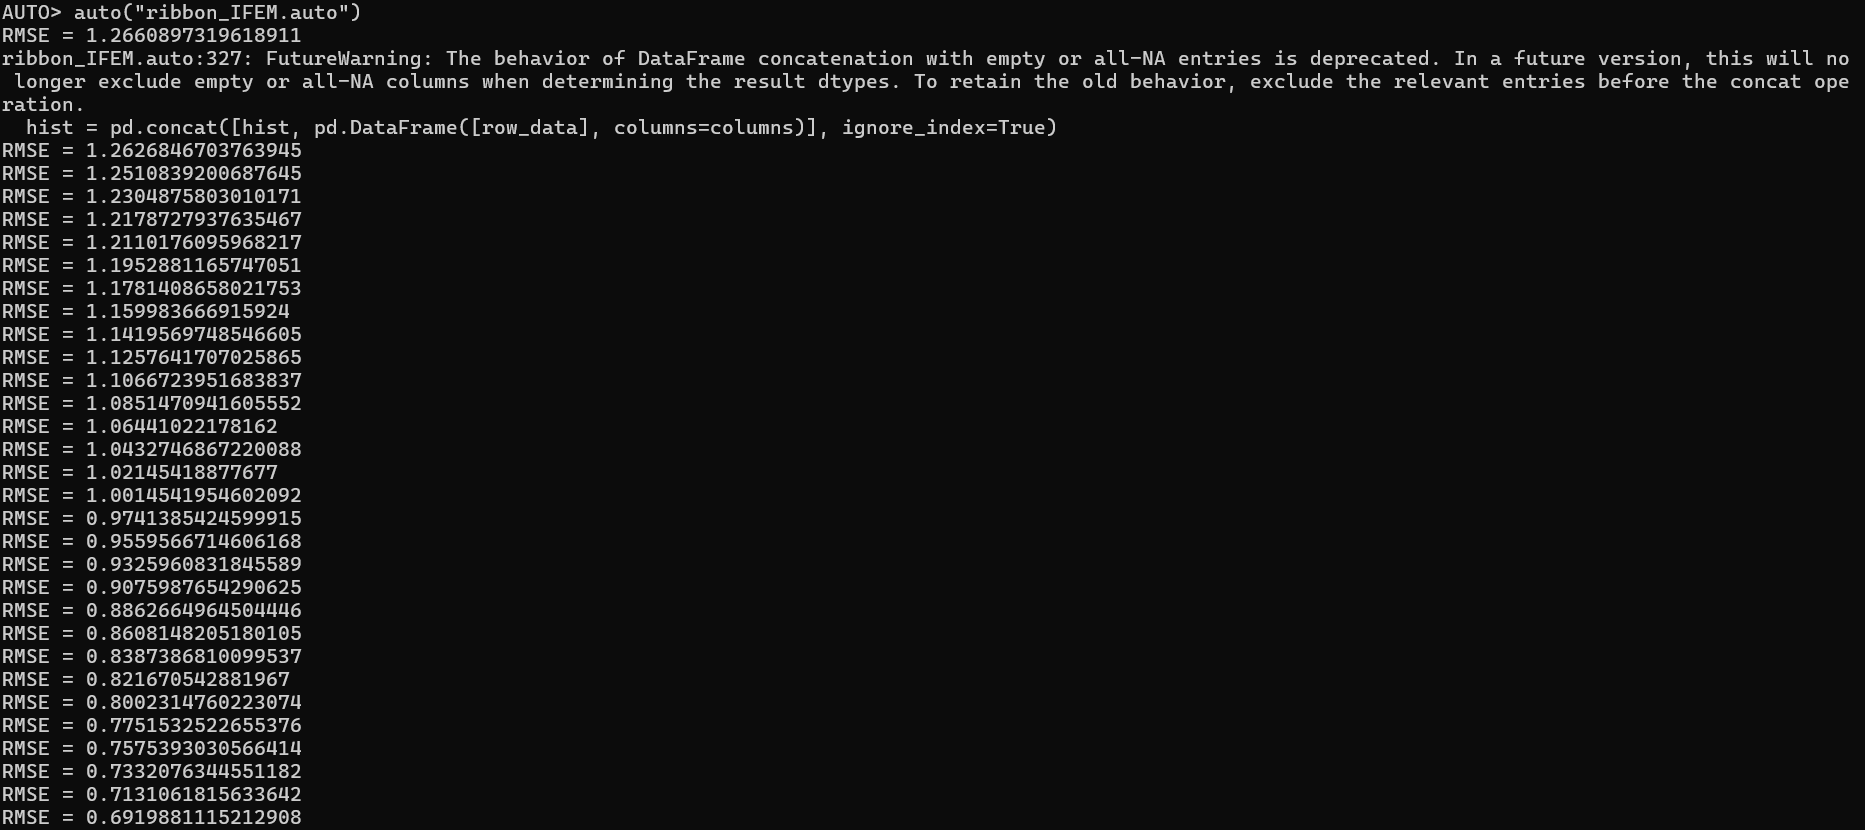

The *RMSE* represent the error between the target configuration (from experimental) and to current configuration. The algorithm tries to minimize this value by changing the parameter that defines the stresses along the ribbon.

## Rest and push simulation (quasi-static simulation)

When you are on the auto environment (activated by running the ````auto```` command), run ````auto("ribbon_push.auto")```` to run the continuation corresponding to the ribbon_rest.f90 and ribbon_push.f90 files that you set up in the pre-processing. This is a typicall output you would get: 

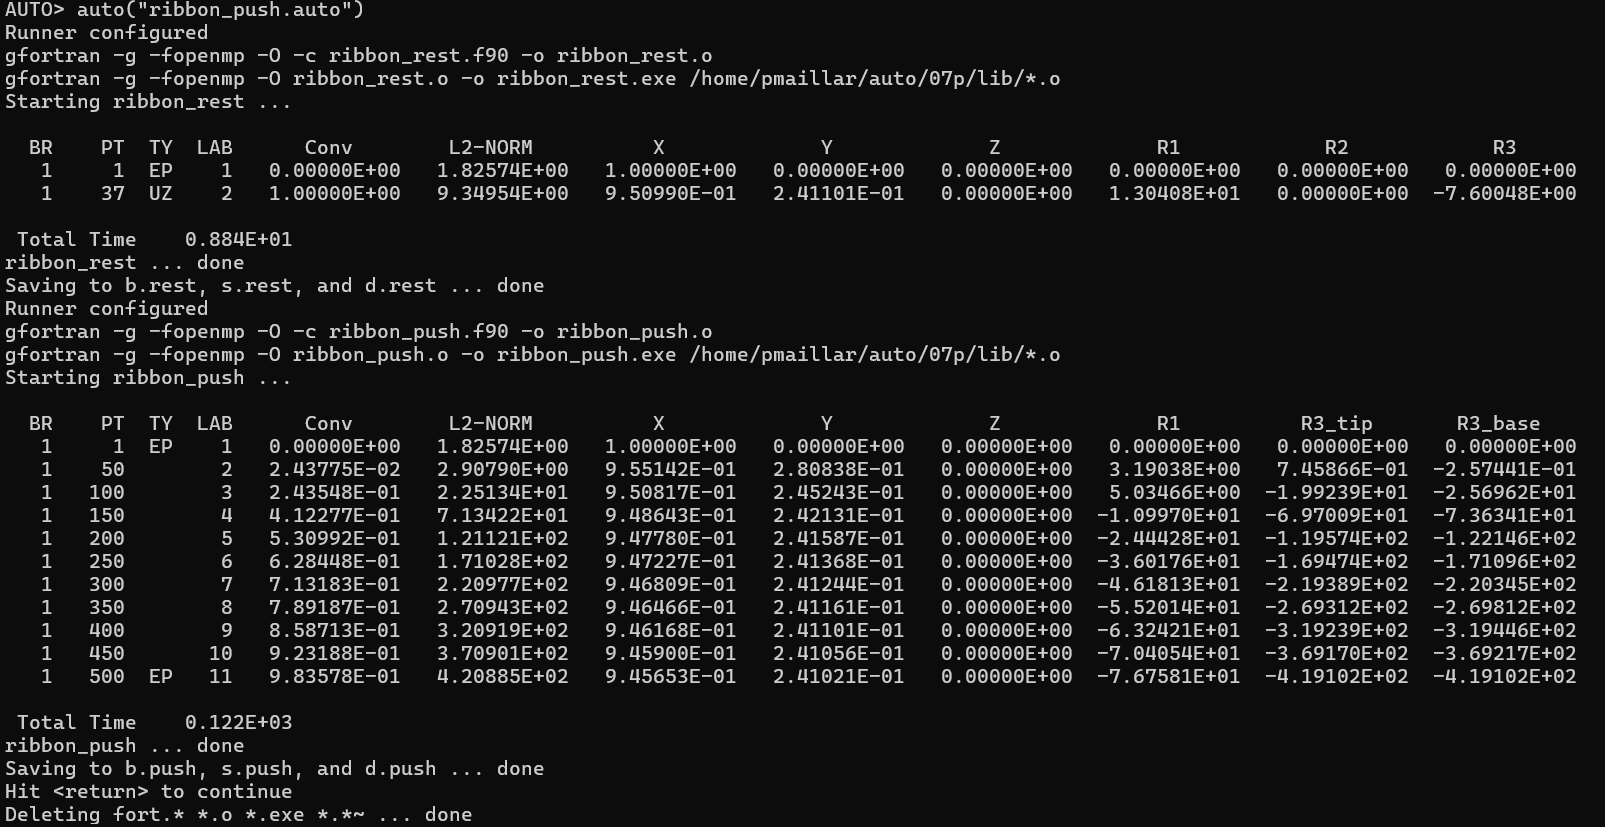

Both simulations are lunch after an other the compute first the steady stat without pushing the ribbon futher into the brain and then a simulation adding the force at the base by relaxing the clamped condition and blocking the displacement of the tip of the ribbon.

# Post-processing

You need to check that the maximal index solution is equal to the number of solutions found in the partition file. If they are not equal, you must reduce the number of points used by auto by lowering the value of NTST inside of the .c file or solve for less case at a time if your a doing a bifurcation analysis.

In [2]:
#Change this according to the position of Auto-07p files on your setup 
path = "//wsl.localhost/Ubuntu/home/pmaillar/auto-07p/Semester_project/auto_files_ribbon/s.mu"

solution_df = process_solution_file(path)
solution_df["Index_solution"].max()


Partition found 10 solutions with 1601 points each


10.0

In [3]:
solution_df.to_csv("auto_solution.csv")

The panda dataframe *solution_df*  now contain every information the you need from the simulation. Please refer at the **user_guide_ribbon_simulation.pdf** for more informations on the output data.

## Plotting the solutions of a continuation

Here we plot the ribbon configuration at various step of the continuation. In our case, continuations are typically used to assure convergence by increasing slowly the stresses apply on the ribbon and to boundary condition. The final solution is the always the solution with the maximum index. It can be usfull the plot various solutions index just to make sure that we obtain the right solution at the end. (That the solutions looks smooth)

In [5]:
fig = plot_3D_ribbons_from_process_solution(solution_df, solution_indices = [10], n_arrows = 3)

Indice of the solution: 10.0
X_max: 0.479
Y_max: 0.452
Z_max: 0.540



## Solutions of the Optimization algorithm

If you have correctly run the optimization, .csv files have been generated to summarize the evolution of the parameter during the run. You will find the optimal parameters on the last row of the last ````hist_x.csv```` file. 

In [3]:
#load the solutions of the 3 exemples
true_solution_twist = pd.read_csv('true_solution_twist.csv')
true_solution_sshape = pd.read_csv('true_solution_sshape.csv')
true_solution_comb = pd.read_csv('true_solution_comb.csv')

In [18]:
#laod the solutions
case_path = 'sshape'

hist_0 = pd.read_csv('output_'+case_path+'/hist_0.csv')
hist_1 = pd.read_csv('output_'+case_path+'/hist_1.csv')
hist_2 = pd.read_csv('output_'+case_path+'/hist_2.csv')
hist_3 = pd.read_csv('output_'+case_path+'/hist_3.csv')
hist_4 = pd.read_csv('output_'+case_path+'/hist_4.csv')
hist_5 = pd.read_csv('output_'+case_path+'/hist_5.csv')

hist_full = pd.concat([hist_0,hist_1,hist_2,hist_3,hist_4, hist_5]).reset_index()
hist_opt = pd.concat([hist_1,hist_2,hist_3,hist_4]).reset_index()

solutions_0 = pd.read_csv('output_'+case_path+'/solutions_0.csv')
solutions_1 = pd.read_csv('output_'+case_path+'/solutions_1.csv')
solutions_2 = pd.read_csv('output_'+case_path+'/solutions_2.csv')
solutions_3 = pd.read_csv('output_'+case_path+'/solutions_3.csv')
solutions_4 = pd.read_csv('output_'+case_path+'/solutions_4.csv')
solutions_5 = pd.read_csv('output_'+case_path+'/solutions_5.csv')

hist_full.head(3)

,index,Iteration,RMSE,Gradient,Param_1,Param_2,Param_3,Param_4,Param_5,Param_6,Step,Mean_Gradient,Variance_Gradient,Alpha
0,0,1,1.222170,[-0.02502273 -0.0132136 -0.03016742 -0.012863...,11.000000,64.000000,6.100000,-1.00000,96.000000,3.750000,[-0.4999998 -0.49999962 -0.49999983 -0.499999...,[-0.00250227 -0.00132136 -0.00301674 -0.001286...,[6.26137227e-06 1.74599129e-06 9.10073521e-06 ...,NaN
1,1,2,1.213171,[-0.00750236 0.00492857 -0.00827496 0.010124...,11.500000,64.500000,6.600000,-0.50000,96.500000,4.250000,[-0.42861663 -0.18411483 -0.42237503 -0.033040...,[-0.00300228 -0.00069637 -0.00354256 -0.000145...,[6.76161193e-06 1.97143939e-06 9.69447678e-06 ...,NaN
2,2,3,1.205985,[0.01064973 0.02078235 0.00879288 0.02680707 0...,11.928616,64.684114,7.022375,-0.46696,96.806176,4.527289,[-0.18604842 0.18430773 -0.22798692 0.258705...,[-0.00163708 0.00145151 -0.00230902 0.002549...,[7.82816377e-06 6.27078712e-06 1.03706799e-05 ...,NaN


### Plotting optimizaiton run 

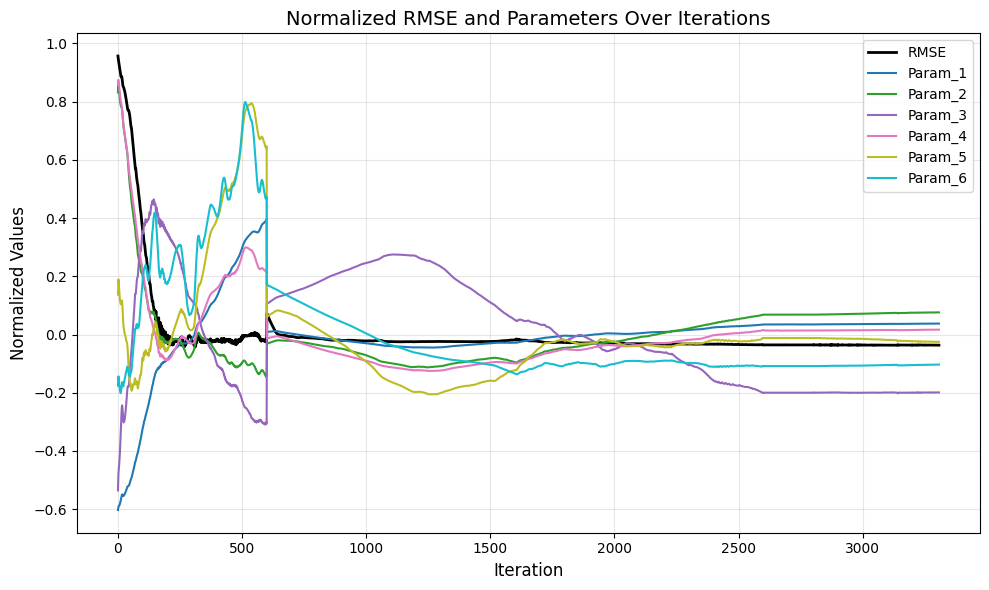

In [5]:
#Plotting of the optimization run

def normalize(data):
    return (data-np.mean(data)) / (data.max()-data.min())


plt.figure(figsize=(10, 6))

# Plot RMSE in black
plt.plot(normalize(hist_full["RMSE"]), color="black", label="RMSE", linewidth=2)

params = [f"Param_{i}" for i in range(1, 7)]
colors = plt.cm.tab10(np.linspace(0, 1, len(params))) 


for i, param in enumerate(params):
    plt.plot(normalize(hist_full[param]), label=param, color=colors[i])

plt.legend(loc="upper right", fontsize=10)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Normalized Values", fontsize=12)
plt.title("Normalized RMSE and Parameters Over Iterations", fontsize=14)
plt.grid(alpha=0.3)

plt.savefig('figure/convergence.png')
# Show the plot
plt.tight_layout()
plt.show()


### Solution of the optimization run
Here we compare the solution of the optimization to the objective configuration. If the objective is generated by a chosen stress configuration, we also display the internal stress of the objective configuration. The yellow curve is the final optimized solution.


Partition found 11 solutions with 1601 points each


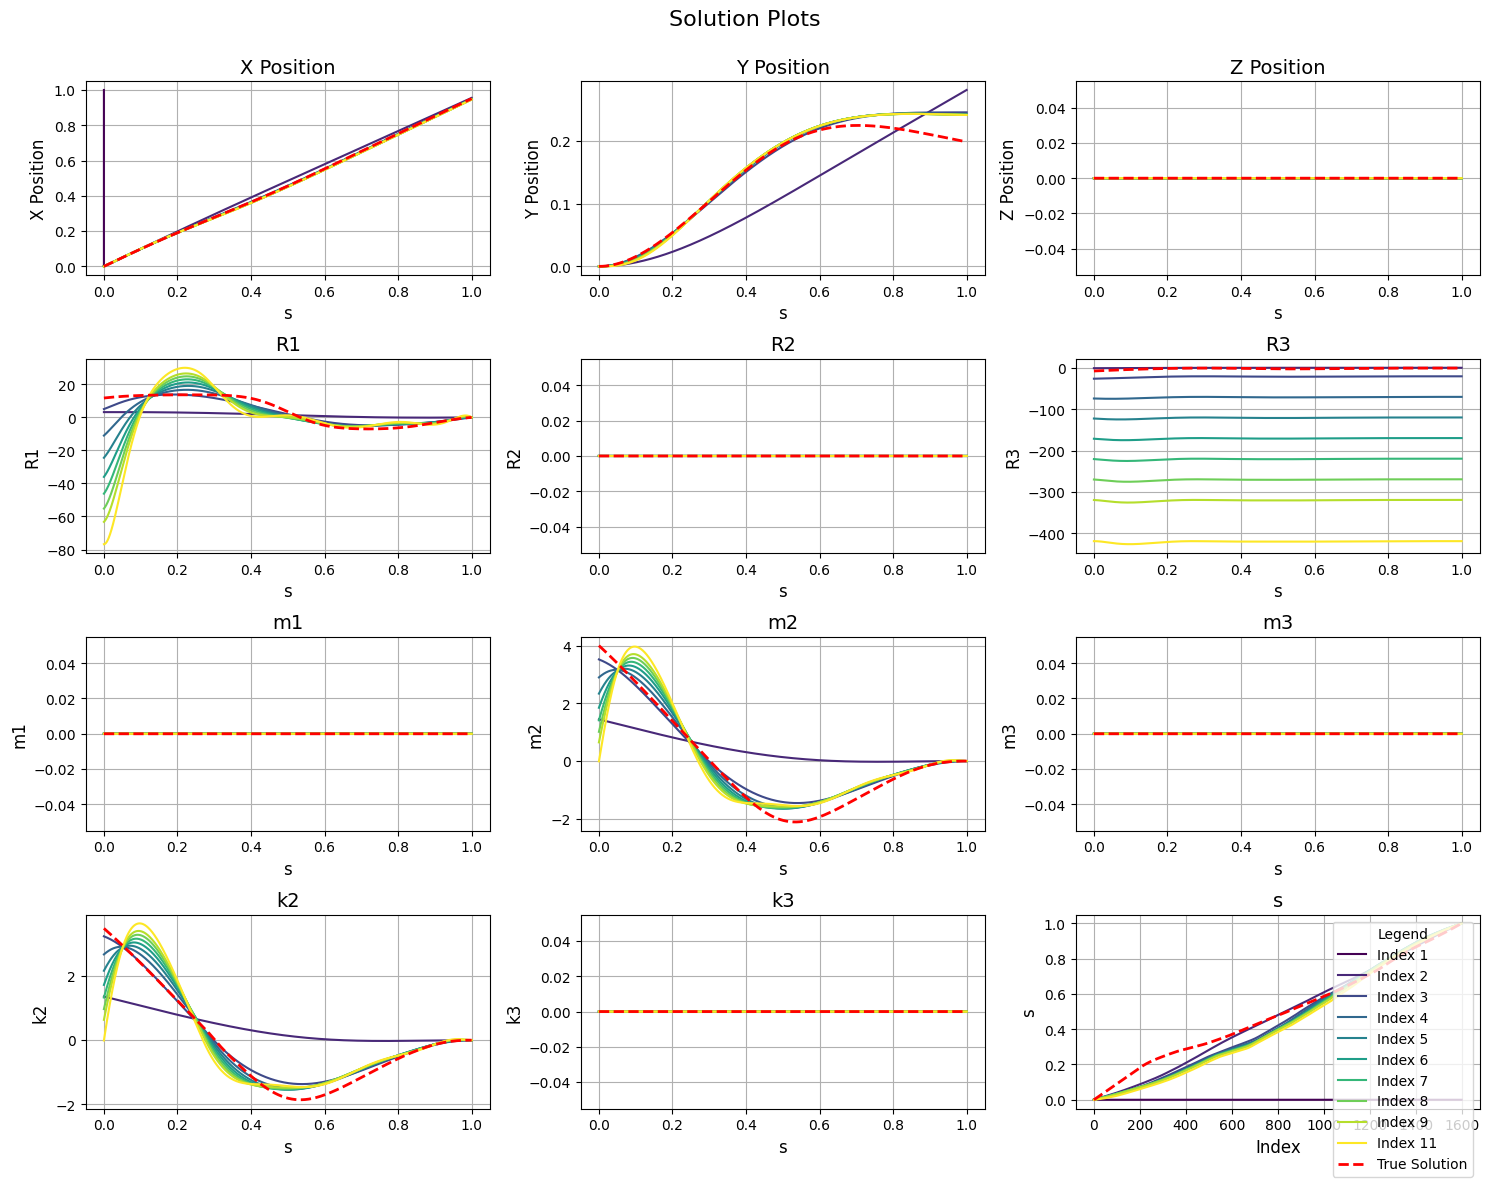

In [7]:
path = "//wsl.localhost/Ubuntu/home/pmaillar/auto-07p/Semester_project/auto_files_ribbon/s.push"

solution = process_solution_file(path)

index = np.linspace(1,max(solution.Index_solution),10,dtype=int)
plot_solution(solution, index,true_solution_sshape)

## Stress field computation

Now we can reconstruct the stress stat on the ribbon using the result of the rest and push simulations.

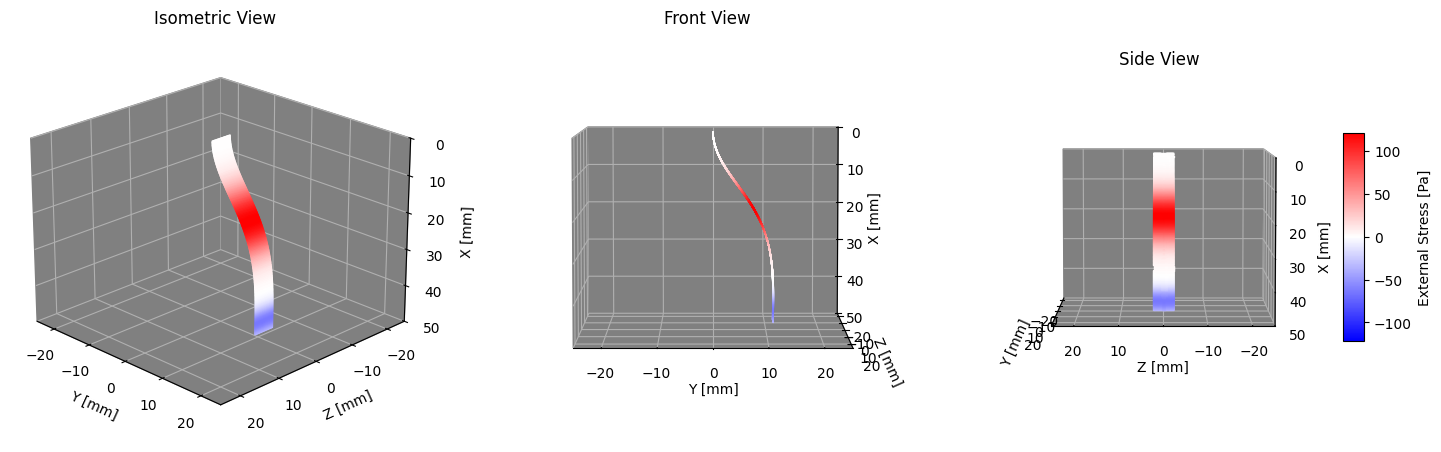

In [5]:
# Example color function with respect to s

L = 50e-3      # Length [m]
t = 0.1e-3     # thikness [m]
a = 5.0e-3     # Width [m]
Y = 2.76e9  # Youngs Modulus of the ribbon [N/m^2]

case_path = 'sshape'

solutions = pd.read_csv('output_'+case_path+'/solutions_5.csv')

Plot_stress_field(hist_full, solutions, 6, Y, a, t, L)


Partition found 2 solutions with 1601 points each

Partition found 11 solutions with 1601 points each


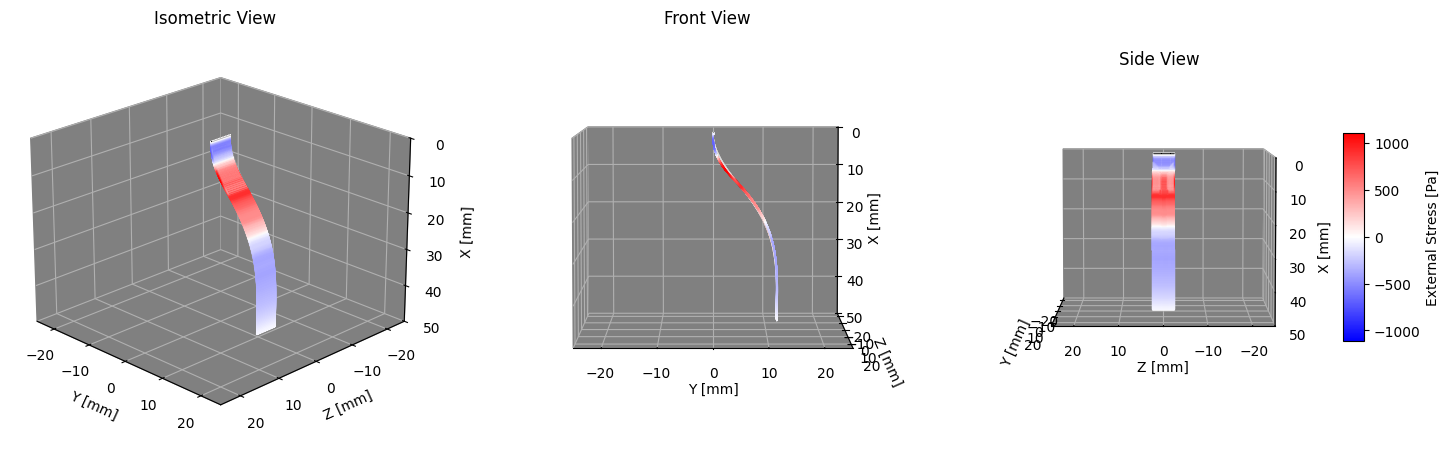

In [11]:
# Load solutions
solutions_ini = process_solution_file("//wsl.localhost/Ubuntu/home/pmaillar/auto-07p/Semester_project/auto_files_ribbon/s.rest")
solutions = process_solution_file("//wsl.localhost/Ubuntu/home/pmaillar/auto-07p/Semester_project/auto_files_ribbon/s.push")

# Constants
L = 50e-3      # Length [m]
t = 0.1e-3     # Thickness [m]
a = 5.0e-3     # Width [m]
Y = 2.76e9     # Young's Modulus [N/m^2]
G_brain = 3.149e3  # Shear modulus [Pa]
nu_brain = 0.45# Poisson's ratio

alpha = [9.619] #parameter of the Ogden hyperelastic model of the brain 
mu = [0.0561e3] #parameter of the Ogden hyperelastic model of the brain 

Plot_rest_and_pushing(hist_full, solutions, solutions_ini, a = a, L = L, Y = Y , t = t, n_para = 6)